In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [5]:
const devisions = 64
const count_iterations = 1024

initial_state = ComplexF64[1;0]
T_gate = ComplexF64[1 0; 0 exp(im*π/(devisions/2))]
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(t)
    return measure(rot_90 * T_gate ^ t * rot_90 * initial_state)
end

function count(n, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(t)
        if measured == 1
            count += 1
        end
    end
    return count
end

function operate(time, Δf)
    iter = time * devisions * Δf
    t_range = range(1, iter)
    data = []
    probs = []
    conv = []
    for i in t_range
        counted = count(count_iterations, i)
        push!(data, counted)
        push!(probs, counted/count_iterations)
        push!(conv, (i * 1/Δf)/devisions)
    end

    return [data, probs, conv]
end

operate (generic function with 1 method)

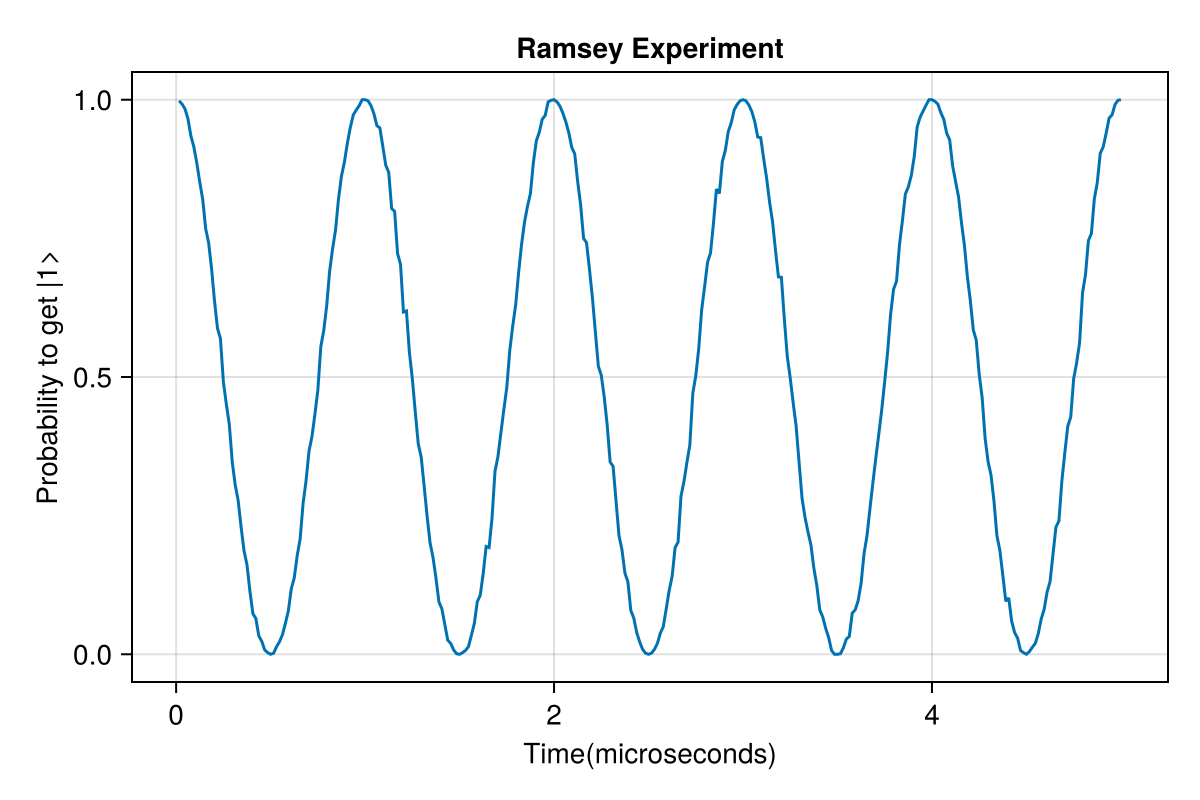

CairoMakie.Screen{IMAGE}


In [ ]:
g = operate(5,1)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, g[3], g[2])
display(fig)

In [7]:
function generate_time(time, Δf)
    iter = time * devisions * Δf
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

function generate_time_2(time, Δf)
    iter = time * devisions
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

generate_time_2 (generic function with 1 method)

In [8]:
generate_time(10,1)

640-element Vector{Any}:
  0.015625
  0.03125
  0.046875
  0.0625
  0.078125
  0.09375
  0.109375
  0.125
  0.140625
  0.15625
  ⋮
  9.875
  9.890625
  9.90625
  9.921875
  9.9375
  9.953125
  9.96875
  9.984375
 10.0

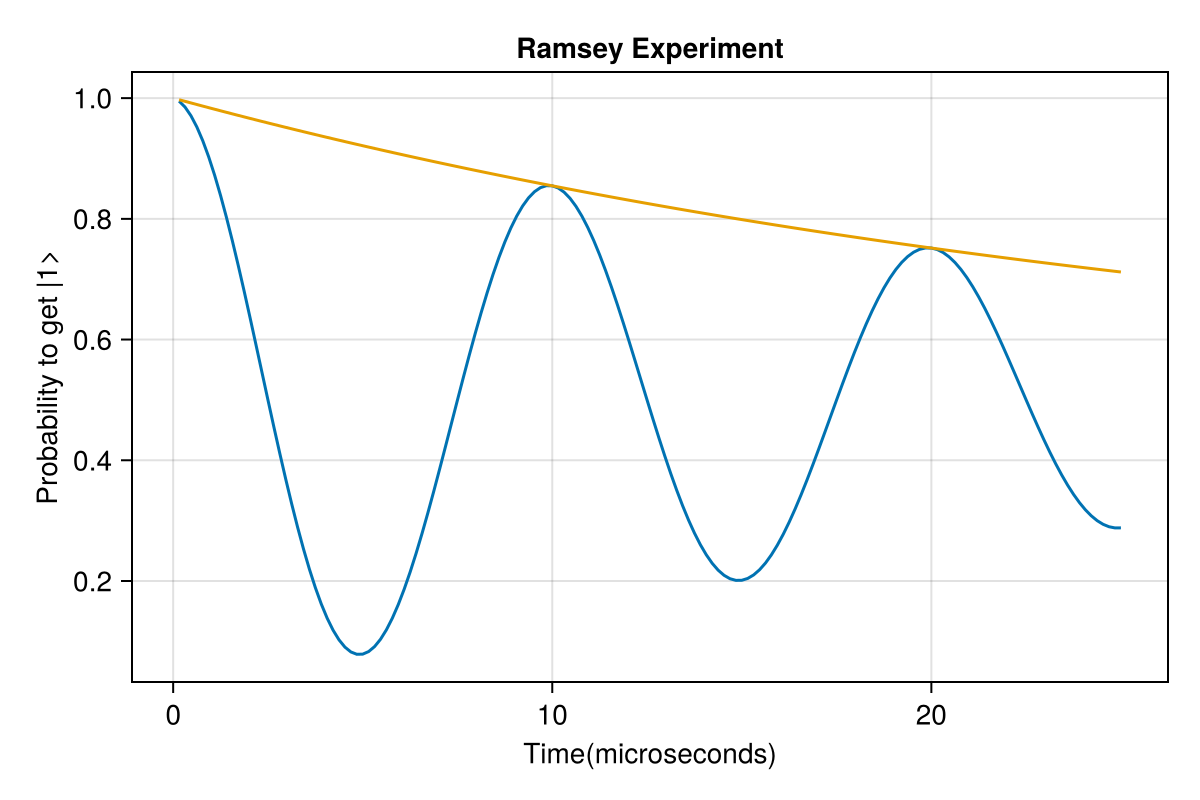

Time to precess(microseconds): 10.0


In [9]:
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000
function Probability_Ramsey(time,Δ)
    Ts = generate_time(time, Δ)   
    function P(t)
        return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
    end

    function border(t)
         return 0.5 * exp(-t/T2x) + 0.5
    end

    decaying = []
    bord= []
    for i in Ts
        push!(decaying, P(i))
        push!(bord, border(i))
    end

    return Ts, decaying, bord
end

Δf = 0.1#MHz
t = 25
Decay = Probability_Ramsey(t, Δf)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Decay[1], Decay[2])
lines!(ax, Decay[1], Decay[3])
display(fig)

println("Time to precess(microseconds): ", 1/Δf)

In [ ]:
Δ = 1
h = 6.626 #* 10**-34
ħ = h/(2*π)
Ω0 = 2π * 0.1
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -im; im  0]
σz = ComplexF64[1 0; 0 -1]


H = ħ/2 * Δ * σz

2×2 Matrix{ComplexF64}:
 0.52728+0.0im       0.0+0.0im
     0.0+0.0im  -0.52728+0.0im

In [149]:
gate_time = 20e-9

T1 = 150e-6
T_ϕ = 200e-6
γ1 = 1/T1
γ_ϕ = 1/T_ϕ

Ω = π / (2 * gate_time)
H_drive = 0.5 * Ω * sigmax()
c_ops = [sqrt(γ1) * sigmam(), sqrt(γ_ϕ) * sigmaz()]
e_ops = [sigmaz()]

function simulate_ramsey(τ,Δ)
    H_base = Δ * sigmaz()

    origin = basis(2,0)

    tlist_flip = range(0.0, gate_time, 201)
    sol = mesolve(H_drive, origin, tlist_flip, c_ops, maxiters = 1e7, progress_bar = false)
    ψ_after_sx = sol.states[end]

    if τ>0
        tlist_moving = range(0.0, τ, 201)
        sol = mesolve(H_base,ψ_after_sx, tlist_moving,c_ops, maxiters = 1e7, progress_bar = false)
    end
    ψ_after_τ = sol.states[end]
    return mesolve(H_drive, ψ_after_τ, tlist_flip, c_ops, e_ops= e_ops, maxiters = 1e7, progress_bar = false)
end

simulate_ramsey (generic function with 1 method)

In [220]:
Ts = range(0, 1e-7, length = 101)
Δs = range(-1e8, 1e8, length = 101)
probs = zeros(length(Δs), length(Ts))
for (i,Δ) in enumerate(Δs)
    for (j, t) in enumerate(Ts)
        probs[i, j] = simulate_ramsey(t, Δ).expect[end] ^ 2
    end
end

In [215]:
function simulate_ramsey_other(τ,Δ)
    H_1 = Qobj([-Δ/2 Ω/2; Ω/2 Δ/2])
    H_2 = Qobj([-Δ/2 0; 0 Δ/2])
    origin = basis(2,0)

    tlist_flip = range(0.0, gate_time, 201)
    sol = mesolve(H_1, origin, tlist_flip, c_ops, maxiters = 1e7, progress_bar = false)
    ψ_after_sx = sol.states[end]

    if τ>0
        tlist_moving = range(0.0, τ, 201)
        sol = mesolve(H_2,ψ_after_sx, tlist_moving,c_ops, maxiters = 1e7, progress_bar = false)
    end
    ψ_after_τ = sol.states[end]
    return mesolve(H_1, ψ_after_τ, tlist_flip, c_ops, e_ops= e_ops, maxiters = 1e7, progress_bar = false)
end


simulate_ramsey_other (generic function with 1 method)

In [222]:
Ts = range(0, 1e-6, length = 101)
Δs = range(-1e8, 1e8, length = 101)
probs = zeros(length(Δs), length(Ts))
for (i,Δ) in enumerate(Δs)
    for (j, t) in enumerate(Ts)
        probs[i, j] = real(simulate_ramsey_other(t, Δ).expect[end]) ^ 2
    end
end

In [217]:
probs

101×101 Matrix{Float64}:
 0.573565  0.941957  0.141304  …  0.636976    0.243159     0.120512
 0.530261  0.966283  0.196066     0.324322    0.0765799    0.646321
 0.486378  0.98413   0.258539     0.320524    0.968564     0.395196
 0.442263  0.995013  0.327544     0.694267    0.13113      0.215998
 0.398279  0.998555  0.401615     0.112607    0.220282     0.725431
 0.354802  0.994493  0.479036  …  0.561662    0.944456     0.255261
 0.312213  0.982696  0.557889     0.634069    0.0414689    0.333689
 0.270895  0.963165  0.636112     0.00595774  0.407628     0.763877
 0.231234  0.936047  0.711561     0.787651    0.843792     0.13731
 0.193607  0.901631  0.782084     0.477436    0.000719958  0.465028
 ⋮                             ⋱                           ⋮
 0.231234  0.936047  0.711561     0.787651    0.843792     0.13731
 0.270895  0.963165  0.636112     0.00595774  0.407628     0.763877
 0.312213  0.982696  0.557889     0.634069    0.0414689    0.333689
 0.354802  0.994493  0.479036  …

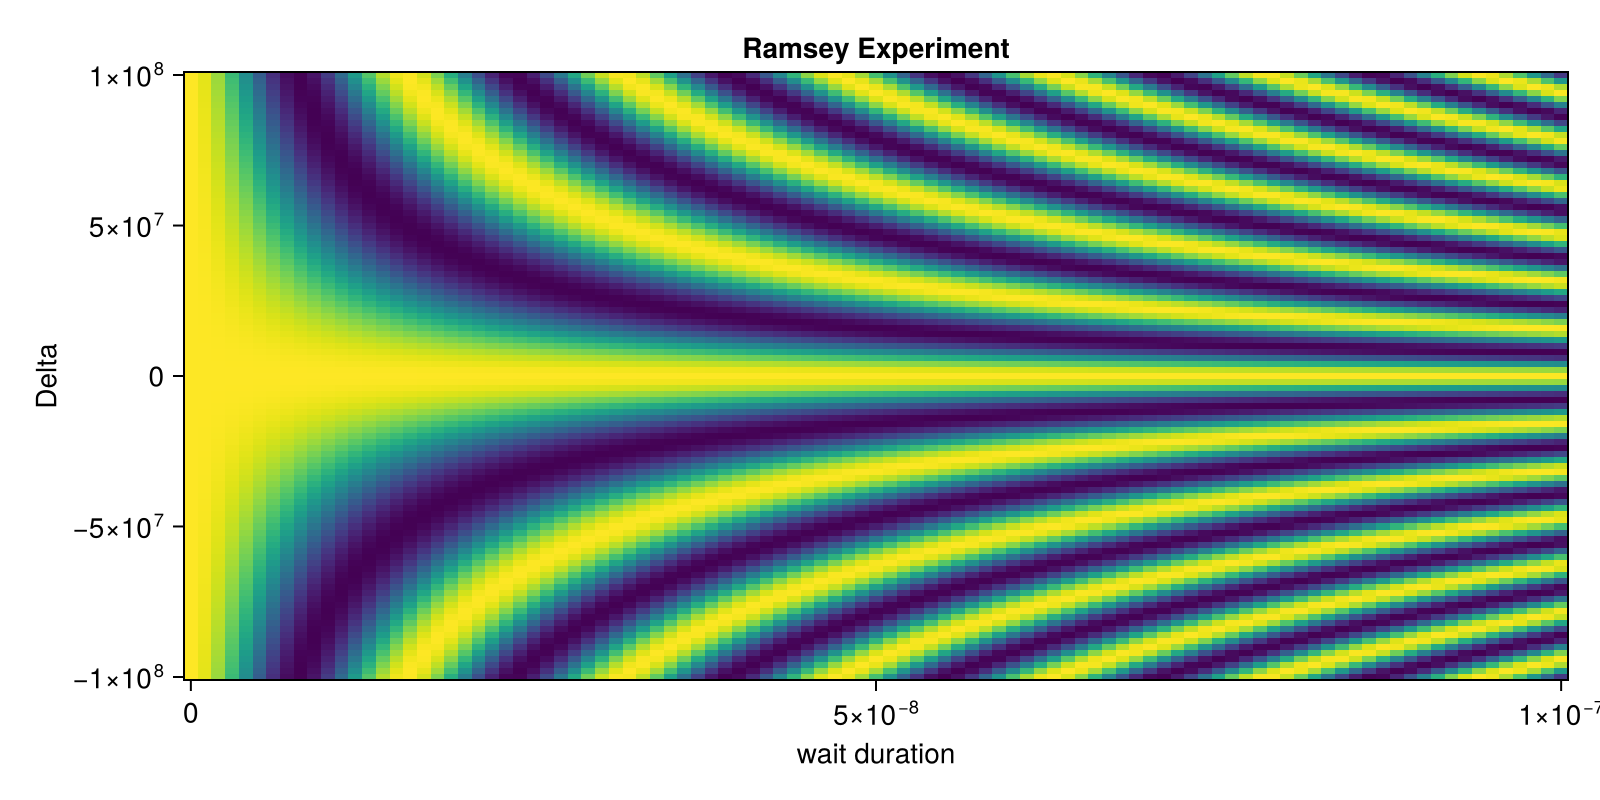

In [221]:
fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "wait duration", ylabel = "Delta")
heatmap!(ax, Ts, Δs, probs')
fig

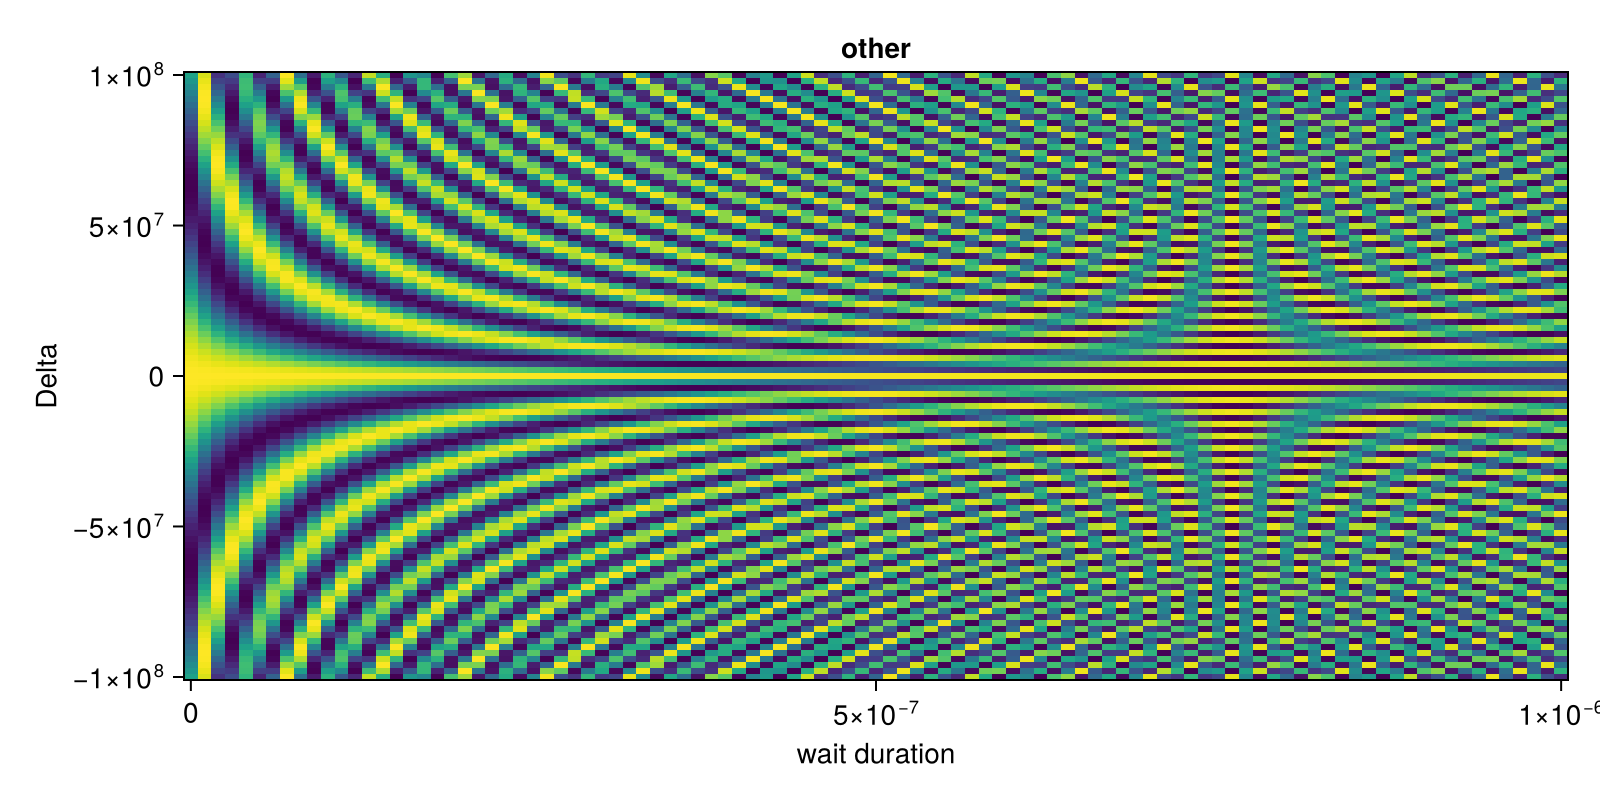

In [219]:
fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1], title = "other", xlabel = "wait duration", ylabel = "Delta")
heatmap!(ax, Ts, Δs, probs')
fig

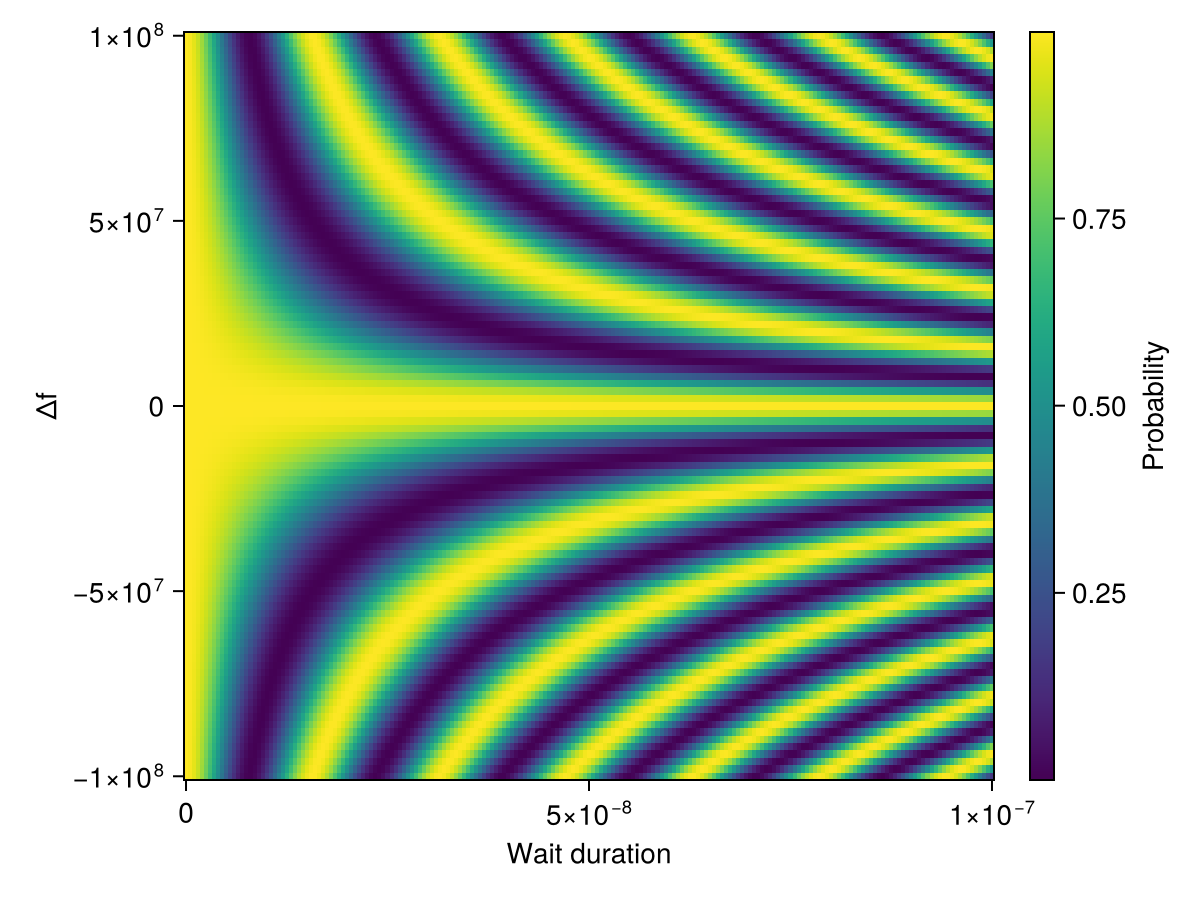

In [175]:
fig, ax, hm = heatmap(Ts, Δs, probs', colormap = :viridis)
ax.ylabel = "Δf"
ax.xlabel = "Wait duration"
Colorbar(fig[:, end+1], hm, label = "Probability")
fig

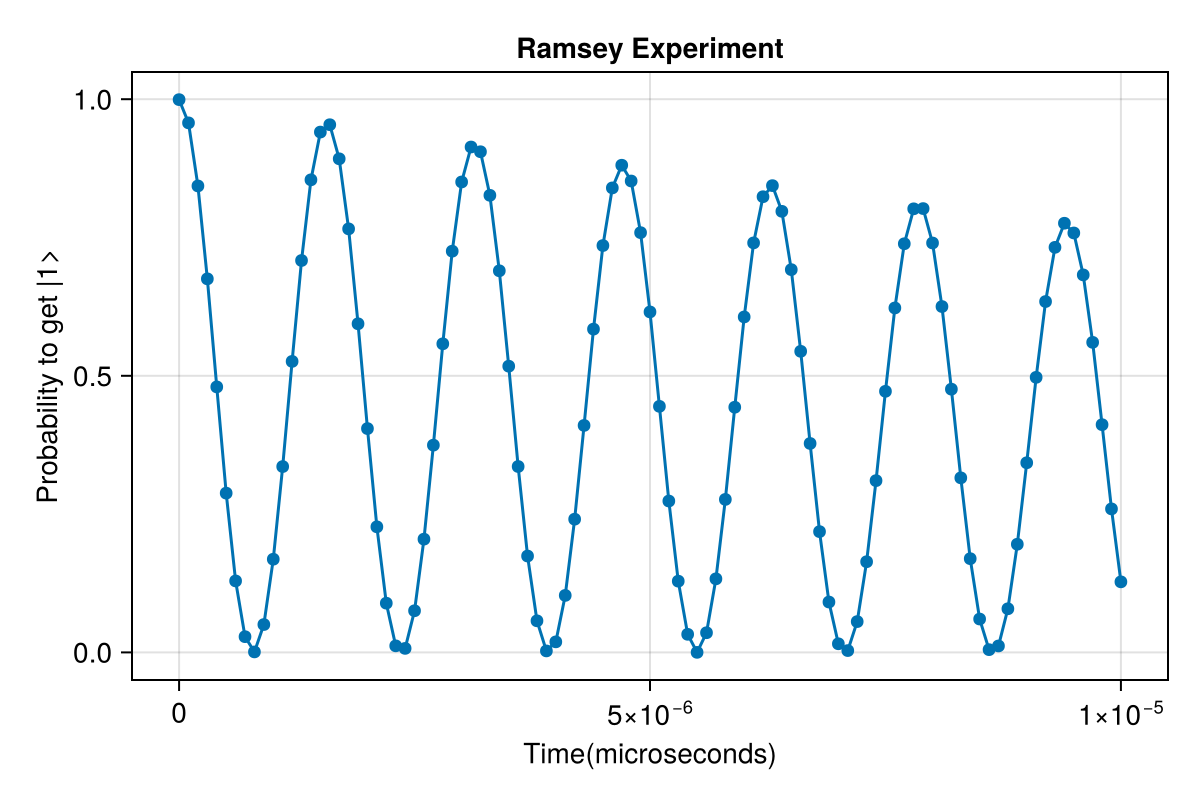

In [247]:
Ts = range(0, 1e-5, length = 101)
Δ = 1e6
probs = zeros(length(Ts))

for (i,t) in enumerate(Ts)
    probs[i] = simulate_ramsey(t,Δ).expect[end]^2
end
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
scatter!(ax, Ts, probs)
lines!(ax, Ts, probs)
fig

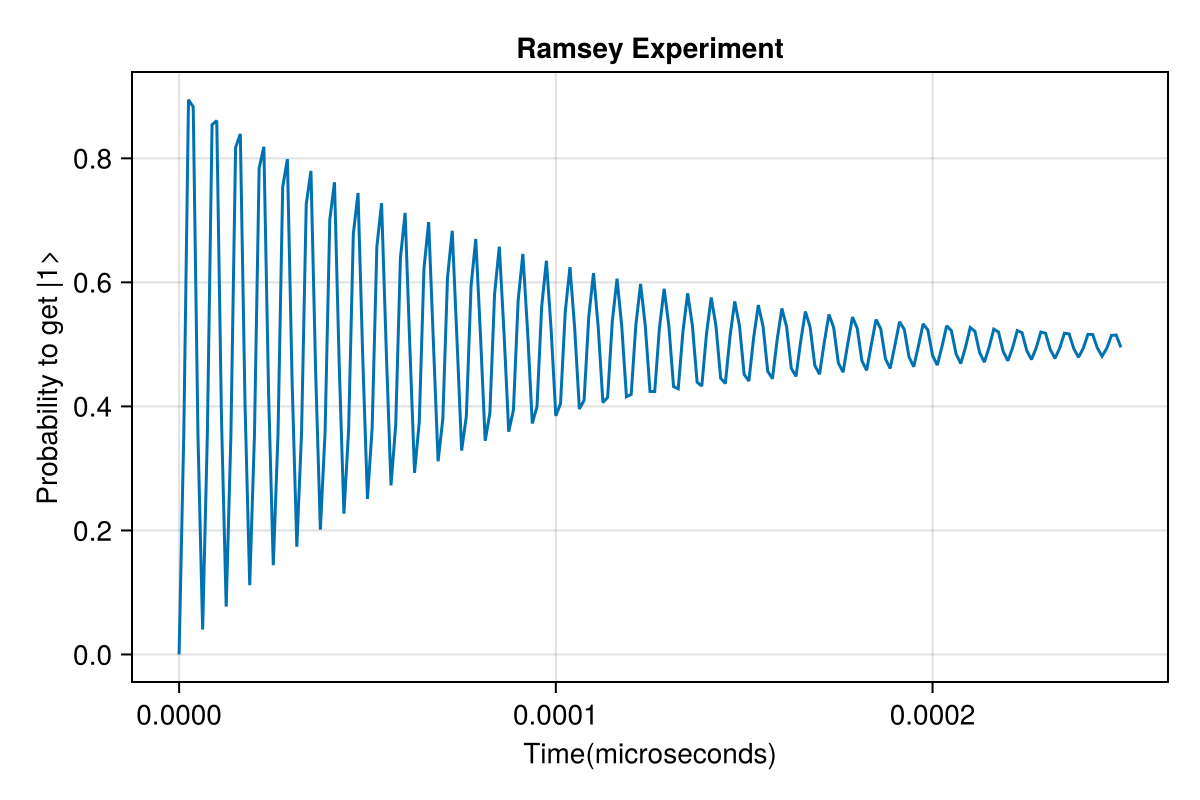

In [270]:
Ts = range(0,2.5e-4, length = 201)
Δ = 1e6
probs = zeros(length(Ts))

for (i,t) in enumerate(Ts)
    probs[i] = real(simulate_ramsey_other(t,Δ).states[1][1])
end
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
#scatter!(ax, Ts, probs)
lines!(ax, Ts, probs)

fig